In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker()

In [ ]:
genders = ["Male", "Female"]
departments = ["CSE", "IT", "ECE"]
years = ["1st", "2nd", "3rd"]

data = []

for i in range(1, 251):
    student = {
        "Student_ID": i,
        "Name": fake.name(),
        "Gender": random.choice(genders),
        "Department": random.choice(departments),
        "Year": random.choice(years),
        "Maths": random.randint(0, 100),
        "Science": random.randint(0, 100),
        "English": random.randint(0, 100),
        "Attendance": random.33(50, 100),
        "Internal_Marks": random.randint(0, 25)
    }
    data.append(student)

df = pd.DataFrame(data)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks
0,1,Melissa Chase,Male,CSE,3rd,98,15,13,75,22
1,2,Lisa Mcclure,Male,CSE,3rd,54,26,84,87,14
2,3,Anthony Ochoa,Male,CSE,3rd,48,80,34,86,20
3,4,Charles Chang MD,Male,IT,1st,51,54,44,96,0
4,5,Whitney Wilson,Female,CSE,3rd,42,71,69,81,13


In [ ]:
print("Missing Values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("\nDataset Shape:", df.shape)

Missing Values:
 Student_ID        0
Name              0
Gender            0
Department        0
Year              0
Maths             0
Science           0
English           0
Attendance        0
Internal_Marks    0
dtype: int64

Dataset Shape: (250, 10)


In [ ]:

df["Total"] = df["Maths"] + df["Science"] + df["English"]


df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"


df["Grade"] = df["Average"].apply(grade)

print(df.head())

   Student_ID              Name  Gender Department Year  Maths  Science  \
0           1     Melissa Chase    Male        CSE  3rd     98       15   
1           2      Lisa Mcclure    Male        CSE  3rd     54       26   
2           3     Anthony Ochoa    Male        CSE  3rd     48       80   
3           4  Charles Chang MD    Male         IT  1st     51       54   
4           5    Whitney Wilson  Female        CSE  3rd     42       71   

   English  Attendance  Internal_Marks  Total    Average Grade  
0       13          75              22    126  42.000000     C  
1       84          87              14    164  54.666667     C  
2       34          86              20    162  54.000000     C  
3       44          96               0    149  49.666667     C  
4       69          81              13    182  60.666667     B  


In [ ]:
df.describe()

,Student_ID,Maths,Science,English,Attendance,Internal_Marks,Total,Average
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,125.500000,51.668000,48.628000,50.628000,76.120000,12.756000,150.924000,50.308000
std,72.312977,29.697771,30.562623,30.073698,14.520502,7.324963,51.693395,17.231132
min,1.000000,0.000000,0.000000,0.000000,50.000000,0.000000,13.000000,4.333333
25%,63.250000,29.000000,20.000000,23.250000,64.000000,7.000000,112.500000,37.500000
50%,125.500000,51.000000,50.000000,52.000000,76.000000,12.000000,151.000000,50.333333
75%,187.750000,79.000000,76.000000,79.000000,89.000000,20.000000,185.000000,61.666667
max,250.000000,100.000000,100.000000,100.000000,100.000000,25.000000,266.000000,88.666667


In [ ]:
top_students = df.sort_values(by="Average", ascending=False).head(5)
fail_students = df[df["Grade"] == "Fail"]

print("Top 5 Students:\n")
print(top_students)

print("\nFail Students:\n")
print(fail_students)

Top 5 Students:

     Student_ID             Name  Gender Department Year  Maths  Science  \
221         222    Makayla Berry    Male        ECE  1st     78       90   
20           21  Anthony Donovan    Male         IT  2nd     87       78   
137         138    Chelsea Burke  Female        CSE  2nd    100       62   
140         141    Annette Mejia    Male        ECE  2nd     99       70   
47           48      Carol Moore    Male        CSE  2nd     83       76   

     English  Attendance  Internal_Marks  Total    Average Grade  
221       98          68              19    266  88.666667     A  
20       100          72               8    265  88.333333     A  
137       97          94               7    259  86.333333     A  
140       85          84               3    254  84.666667     A  
47        95          76              13    254  84.666667     A  

Fail Students:

     Student_ID                  Name  Gender Department Year  Maths  Science  \
13           14  Christoph

In [ ]:
print("Department-wise Average:\n")
print(df.groupby("Department")["Average"].mean())

print("\nGender-wise Average:\n")
print(df.groupby("Gender")["Average"].mean())

print("\nYear-wise Average:\n")
print(df.groupby("Year")["Average"].mean())

Department-wise Average:

Department
CSE    48.421456
ECE    50.905303
IT     51.795556
Name: Average, dtype: float64

Gender-wise Average:

Gender
Female    50.602469
Male      49.962319
Name: Average, dtype: float64

Year-wise Average:

Year
1st    50.846743
2nd    48.607306
3rd    51.166667
Name: Average, dtype: float64


/tmp/ipykernel_2255/345644402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Department", y="Average", data=df, palette="coolwarm")


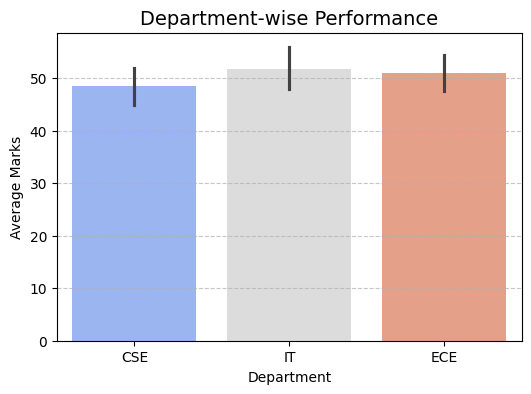

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="Department", y="Average", data=df, palette="coolwarm")

plt.title("Department-wise Performance", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Average Marks")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

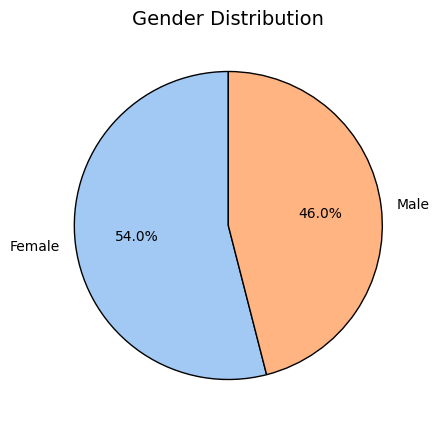

In [ ]:
plt.figure(figsize=(5,5))

colors = sns.color_palette("pastel")
df["Gender"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Gender Distribution", fontsize=14)
plt.ylabel("")
plt.show()

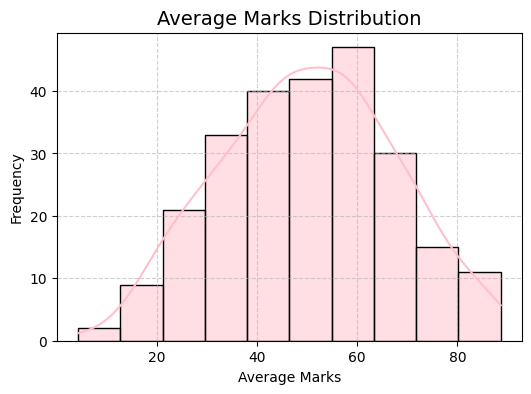

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df["Average"], bins=10, kde=True,color="pink")

plt.title("Average Marks Distribution", fontsize=14)
plt.xlabel("Average Marks")
plt.ylabel("Frequency")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

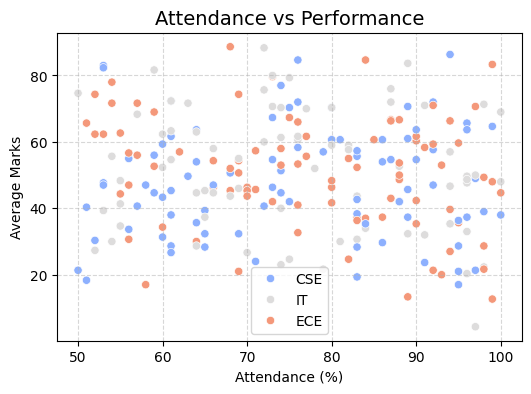

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Attendance",
    y="Average",
    data=df,
    hue="Department",
    palette="coolwarm"
)

plt.title("Attendance vs Performance", fontsize=14)
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

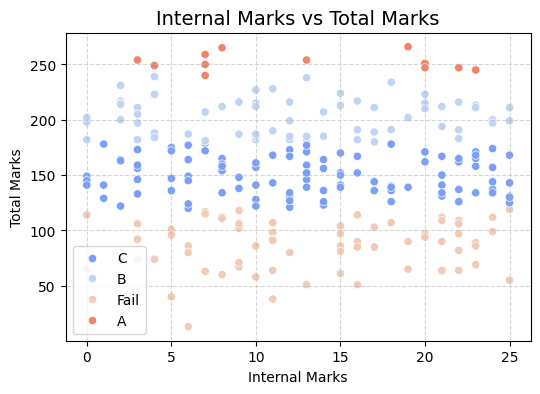

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Internal_Marks",
    y="Total",
    data=df,
    hue="Grade",
    palette="coolwarm"
)

plt.title("Internal Marks vs Total Marks", fontsize=14)
plt.xlabel("Internal Marks")
plt.ylabel("Total Marks")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()